## Importy i wczytanie danych

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/ObesityDataSet_raw_and_data_sinthetic.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## Analiza danych

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

In [4]:
target_counts = df['NObeyesdad'].value_counts()
print(target_counts)
print(f"\nKlas: {df['NObeyesdad'].nunique()}")
print(f"Min/max liczność: {target_counts.min()} / {target_counts.max()}")
print(f"Stosunek: {target_counts.max() / target_counts.min():.2f}")

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

Klas: 7
Min/max liczność: 272 / 351
Stosunek: 1.29


In [5]:
print(f"NaN w całym df: {df.isnull().sum().sum()}")
print(f"Duplikaty: {df.duplicated().sum()}")

NaN w całym df: 0
Duplikaty: 24


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2111.0,24.312600,6.345968,14.00,19.947192,22.777890,26.000000,61.00
Height,2111.0,1.701677,0.093305,1.45,1.630000,1.700499,1.768464,1.98
Weight,2111.0,86.586058,26.191172,39.00,65.473343,83.000000,107.430682,173.00
FCVC,2111.0,2.419043,0.533927,1.00,2.000000,2.385502,3.000000,3.00
NCP,2111.0,2.685628,0.778039,1.00,2.658738,3.000000,3.000000,4.00
CH2O,2111.0,2.008011,0.612953,1.00,1.584812,2.000000,2.477420,3.00
FAF,2111.0,1.010298,0.850592,0.00,0.124505,1.000000,1.666678,3.00
TUE,2111.0,0.657866,0.608927,0.00,0.000000,0.625350,1.000000,2.00


In [7]:
df.describe(include='str').T

,count,unique,top,freq
Gender,2111,2,Male,1068
family_history_with_overweight,2111,2,yes,1726
FAVC,2111,2,yes,1866
CAEC,2111,4,Sometimes,1765
SMOKE,2111,2,no,2067
SCC,2111,2,no,2015
CALC,2111,4,Sometimes,1401
MTRANS,2111,5,Public_Transportation,1580
NObeyesdad,2111,7,Obesity_Type_I,351


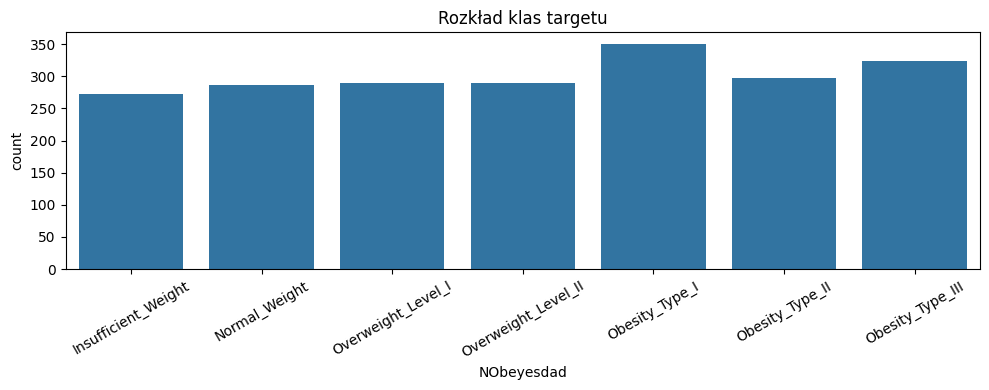

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
order = ['Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I', 
         'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
sns.countplot(data=df, x='NObeyesdad', order=order, ax=ax)
ax.set_title('Rozkład klas targetu')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

Sprawdzam czy BMI się pokrywa z targetem, jeśli tak to nie ma sensu tego zostawiać, bo nie o to chodzi w zadaniu. Lepiej kierować się codziennymi nawykami, aby wytrenować model bardziej zgodny z zadaniem.

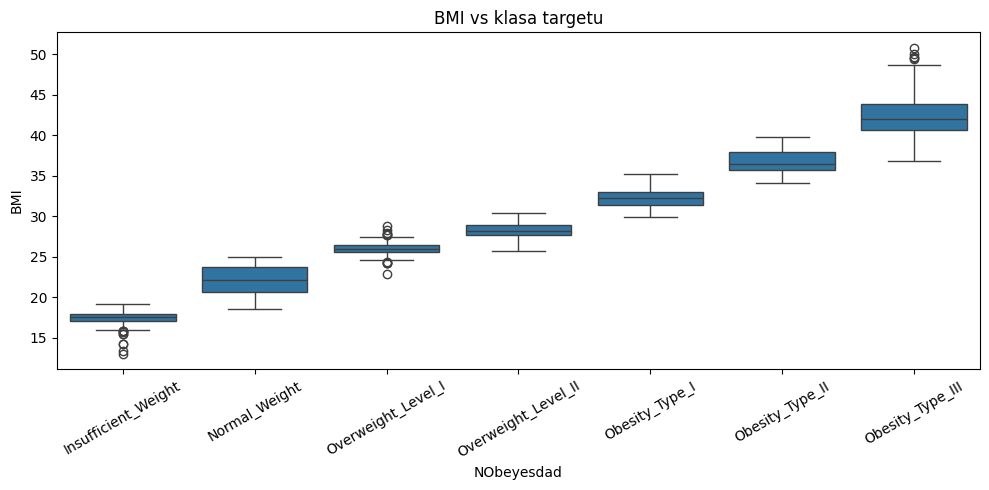

In [9]:
df_check = df.copy()
df_check['BMI'] = df_check['Weight'] / (df_check['Height'] ** 2)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_check, x='NObeyesdad', y='BMI', order=order, ax=ax)
ax.set_title('BMI vs klasa targetu')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

df_check = df.copy()
df_check['BMI'] = df_check['Weight'] / (df_check['Height'] ** 2)

X_bmi = df_check[['BMI']]
y_check = df_check['NObeyesdad']

scores = cross_val_score(DecisionTreeClassifier(random_state=42), X_bmi, y_check, cv=5)
print(f"Accuracy drzewa decyzyjnego na samym BMI: {scores.mean():.4f}")

Accuracy drzewa decyzyjnego na samym BMI: 0.9351


Wykres BMI vs klasa pokazuje, że pudełka prawie się nie nakładają. Jeśli target jest funkcją Weight i Height (BMI), pozostawienie ich w danych zrobiłoby z zadania bardzo łatwy problem, w którym każdy model osiągnąłby prawie 100% accuracy i ciężko byłoby jakkolwiek porównać algorytmy.

Również drzewo wytrenowane na samym BMI daje aż 93.5% accuracy.

Dodatkowo nie ma to sensu praktycznego: gdyby lekarz miał wagę pacjenta, BMI policzyłby kalkulatorem i model byłby zbędny. Realny sens modelu to przewidywanie ryzyka na podstawie stylu życia, dlatego usuwam obie kolumny.

In [11]:
print(df.shape)
df = df.drop_duplicates().reset_index(drop=True)
df = df.drop(columns=['Weight', 'Height'])
print(f"Po usunięciu {df.shape}")

(2111, 17)
Po usunięciu (2087, 15)


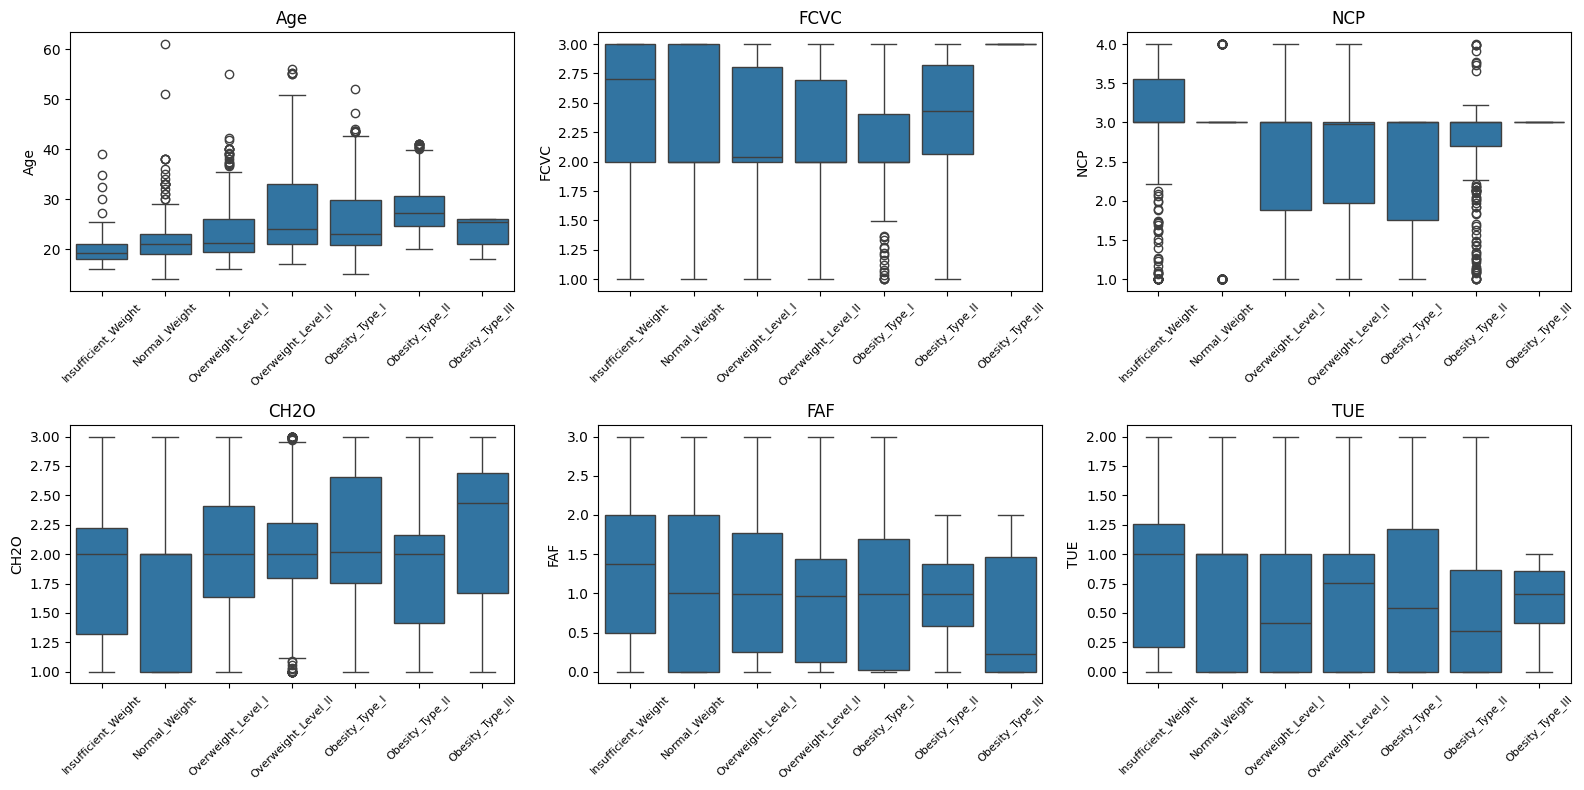

In [12]:
num_cols = ['Age', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(data=df, x='NObeyesdad', y=col, order=order, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

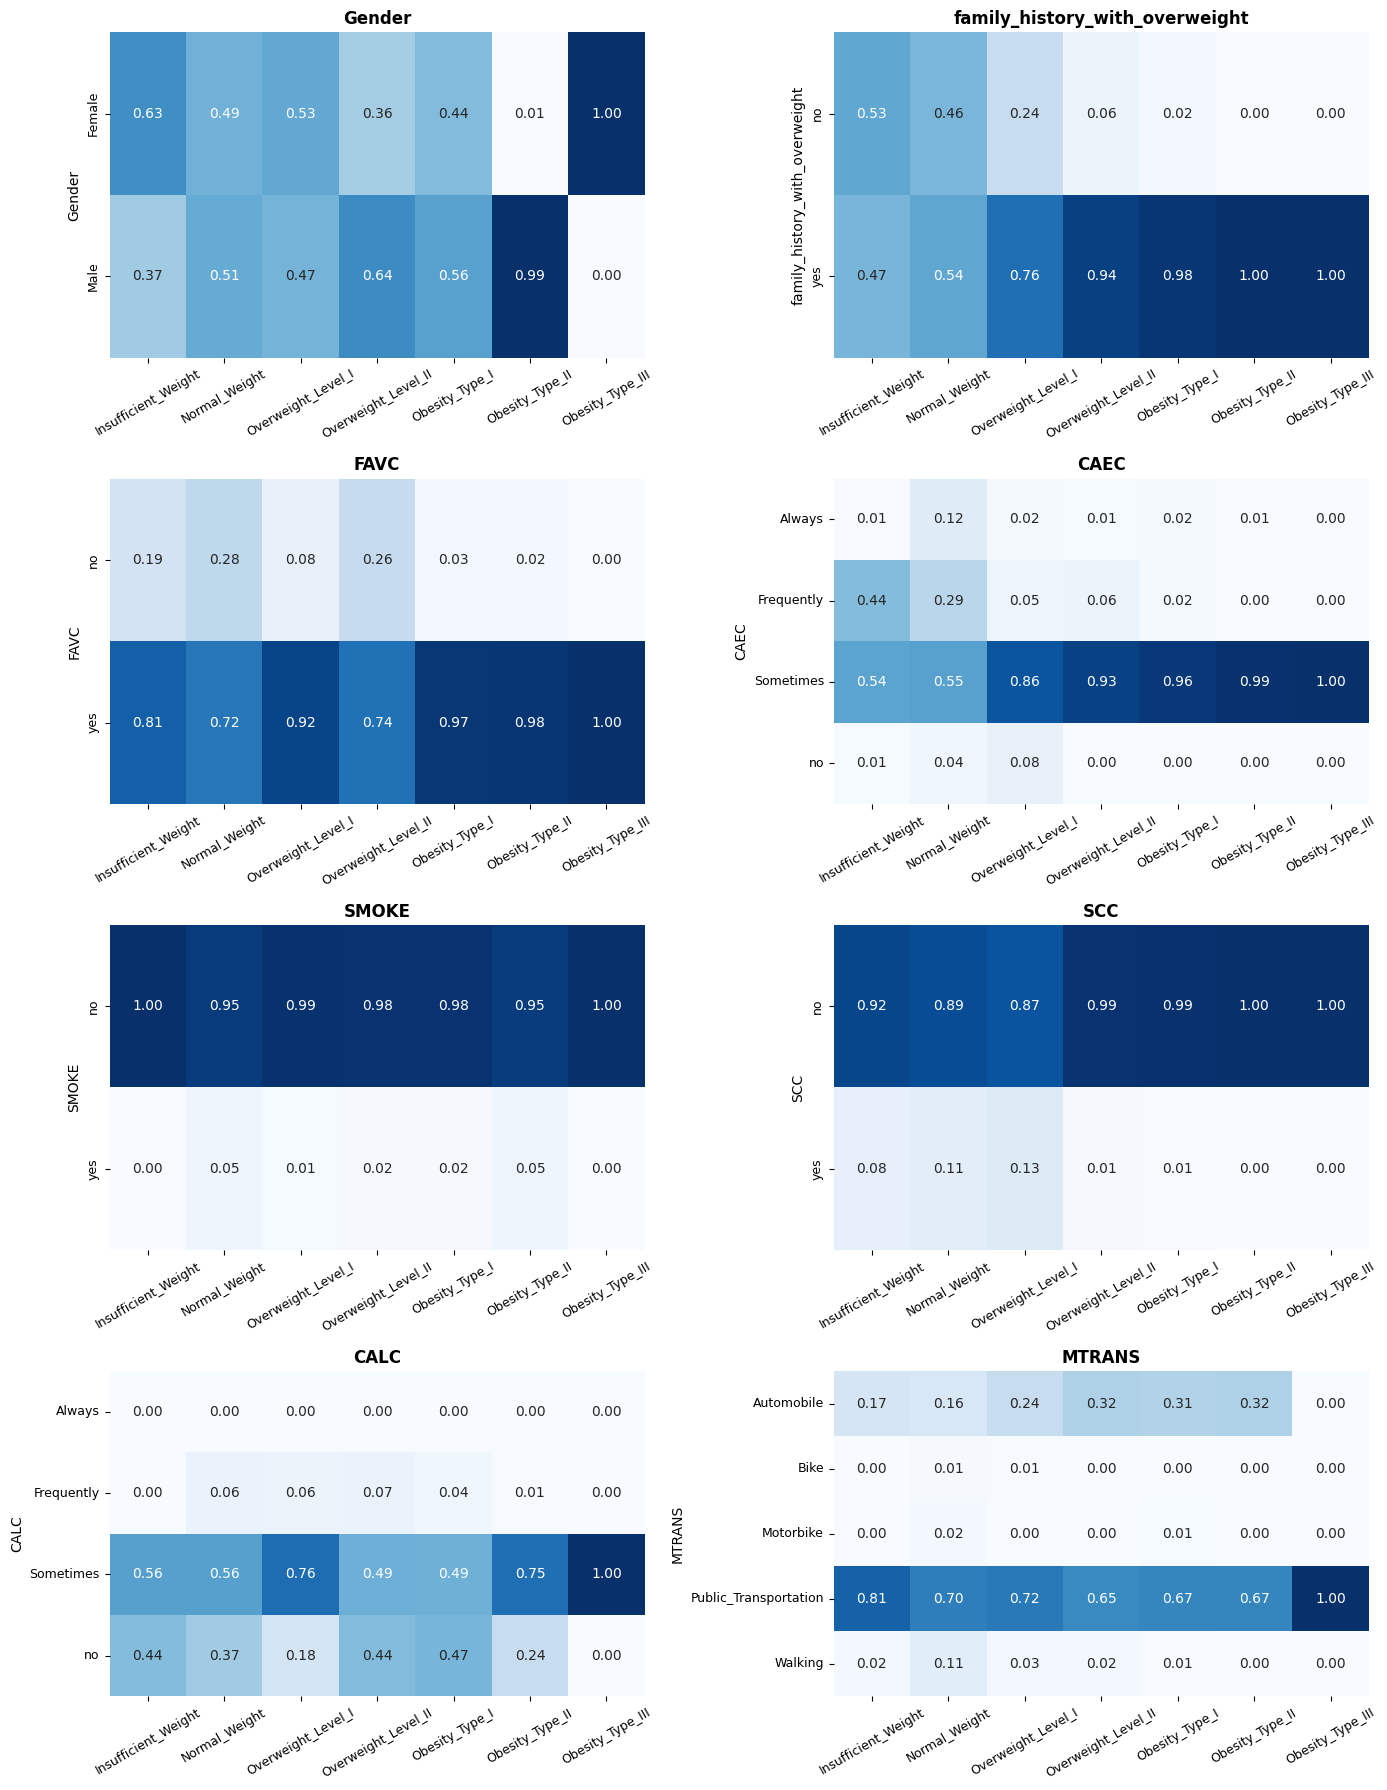

In [13]:
cat_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 
            'SMOKE', 'SCC', 'CALC', 'MTRANS']

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
for ax, col in zip(axes.flat, cat_cols):
    ct = pd.crosstab(df[col], df['NObeyesdad'], normalize='columns').loc[:, order]
    sns.heatmap(ct, annot=True, fmt='.2f', cmap='Blues', ax=ax, 
                cbar=False, annot_kws={'size': 10})
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.show()

## Podsumowanie EDA

Po usunięciu 24 duplikatów i kolumn Weight, Height zostało 2087 obserwacji i 14 cech. Target ma 7 zbalansowanych klas, brak braków danych.

Najmocniej różnicują klasy: family_history (od 46% "yes" w najlżejszej do 100% w najcięższej klasie), FAF (aktywność spada wraz z klasą), CAEC, FAVC. Gender też silnie dzieli klasy, ale rozkład wygląda na błąd wynikający ze sposobu tworzenia danych, a nie realną zależność.

Skoro nie ma cech o sile podobnej do BMI, nie spodziewam się wysokiego accuracy. Drzewa i modele oparte na drzewach powinny tu być lepsze od regresji logistycznej, bo dane mają silne nieliniowe interakcje.

## Preprocessing

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

X = df.drop(columns=['NObeyesdad'])
y = df['NObeyesdad']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(exclude='number').columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Numeryczne: {num_cols}")
print(f"Kategoryczne: {cat_cols}")

Train: (1565, 14), Test: (522, 14)
Numeryczne: ['Age', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
Kategoryczne: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
import time

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    """Trenuje model, mierzy metryki, czas predykcji i pewność."""
    pipe = Pipeline([('prep', preprocessor), ('clf', model)])
    
    # trening
    pipe.fit(X_train, y_train)
    
    # czas predykcji 
    times = []
    for _ in range(10):
        t0 = time.perf_counter()
        y_pred = pipe.predict(X_test)
        times.append(time.perf_counter() - t0)
    pred_time = np.mean(times) * 1000  # ms
    
    # metryki
    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    
    # confidence
    if hasattr(pipe, 'predict_proba'):
        try:    
            proba = pipe.predict_proba(X_test)
            confidence = np.mean(np.max(proba, axis=1))
        except AttributeError:
            confidence = np.nan
    else:
        confidence = np.nan
    
    return {
        'model': name,
        'accuracy': acc,
        'balanced_acc': bal_acc,
        'f1_macro': f1,
        'confidence': confidence,
        'pred_time_ms': pred_time,
    }

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

results = []

results.append(evaluate_model(
    'DecisionTree',
    DecisionTreeClassifier(random_state=42),
    X_train, X_test, y_train, y_test
))

results.append(evaluate_model(
    'LogisticRegression',
    LogisticRegression(max_iter=2000, random_state=42),
    X_train, X_test, y_train, y_test
))

pd.DataFrame(results).round(4)

,model,accuracy,balanced_acc,f1_macro,confidence,pred_time_ms
0,DecisionTree,0.7433,0.7396,0.7362,1.0000,3.3124
1,LogisticRegression,0.6360,0.6248,0.6004,0.5827,6.5734


## Bagging

Trzy warianty bazowe + analiza wpływu parametrów.

In [17]:
from sklearn.ensemble import BaggingClassifier

bagging_results = []

bagging_results.append(evaluate_model(
    'Bagging(shallow_tree, max_depth=3)',
    BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=3, random_state=42),
        n_estimators=50, random_state=42, n_jobs=-1
    ),
    X_train, X_test, y_train, y_test
))

bagging_results.append(evaluate_model(
    'Bagging(deep_tree)',
    BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=50, random_state=42, n_jobs=-1
    ),
    X_train, X_test, y_train, y_test
))

bagging_results.append(evaluate_model(
    'Bagging(LogReg)',
    BaggingClassifier(
        estimator=LogisticRegression(max_iter=2000, random_state=42),
        n_estimators=50, random_state=42, n_jobs=-1
    ),
    X_train, X_test, y_train, y_test
))

pd.DataFrame(bagging_results).round(4)

,model,accuracy,balanced_acc,f1_macro,confidence,pred_time_ms
0,"Bagging(shallow_tree, max_depth=3)",0.5000,0.4777,0.4055,0.4523,34.6516
1,Bagging(deep_tree),0.7893,0.7851,0.7842,0.7641,37.8020
2,Bagging(LogReg),0.6303,0.6191,0.5957,0.5813,32.2123


In [18]:
n_values = [5, 10, 25, 50, 100, 200]
n_results = []

for n in n_values:
    r = evaluate_model(
        f'Bagging_n={n}',
        BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=42),
            n_estimators=n, random_state=42, n_jobs=-1
        ),
        X_train, X_test, y_train, y_test
    )
    r['n_estimators'] = n
    n_results.append(r)

df_n = pd.DataFrame(n_results)

df_n[['n_estimators','accuracy','confidence','pred_time_ms']].round(2)

,n_estimators,accuracy,confidence,pred_time_ms
0,5,0.78,0.82,16.46
1,10,0.77,0.78,15.84
2,25,0.80,0.77,429.21
3,50,0.79,0.76,36.00
4,100,0.79,0.76,49.75
5,200,0.79,0.76,74.96


In [19]:
combinations = [
    (True, False),
    (False, False),
    (True, True),
    (False, True), 
]

bootstrap_results = []
for bs, bsf in combinations:
    r = evaluate_model(
        f'bootstrap={bs}, features={bsf}',
        BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=42),
            n_estimators=50,
            bootstrap=bs, bootstrap_features=bsf,
            random_state=42, n_jobs=-1
        ),
        X_train, X_test, y_train, y_test
    )
    bootstrap_results.append(r)

pd.DataFrame(bootstrap_results).round(4)

,model,accuracy,balanced_acc,f1_macro,confidence,pred_time_ms
0,"bootstrap=True, features=False",0.7893,0.7851,0.7842,0.7641,38.8417
1,"bootstrap=False, features=False",0.7625,0.7578,0.7565,0.9425,42.4130
2,"bootstrap=True, features=True",0.8333,0.8305,0.8311,0.6854,39.6508
3,"bootstrap=False, features=True",0.8410,0.8384,0.8394,0.7184,39.5620


### Podsumowanie Baggingu

Płytkie drzewa (max_depth=3) w baggingu nie zadziałały, dały tylko 50% accuracy. Bagging redukuje wariancję, a tu problem był z biasem (underfittingiem). Bagging z regresją logistyczną dał ten sam wynik co sama regresja, bo modele liniowe i tak mają niską wariancję.

Głębokie drzewa w baggingu dały realny zysk: 78.9% accuracy względem 74.3% pojedynczego drzewa, a pewność modelu spadła z 1.0 do 0.76, co znaczy że model lepiej wie kiedy się myli.

Powyżej 25-50 estymatorów accuracy się nie zmienia, większe wartości tylko spowalniają predykcję bez żadnego zysku.

Losowanie cech (bootstrap_features=True) daje większą poprawę niż losowanie wierszy. Najlepszy wariant osiągnął 84.1% accuracy.

## Boosting

In [20]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

boost_results = []

boost_results.append(evaluate_model(
    'AdaBoost(stump, depth=1)',
    AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
        n_estimators=100, learning_rate=1.0, random_state=42
    ),
    X_train, X_test, y_train, y_test
))

boost_results.append(evaluate_model(
    'AdaBoost(tree, depth=3)',
    AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3, random_state=42),
        n_estimators=100, learning_rate=1.0, random_state=42
    ),
    X_train, X_test, y_train, y_test
))

boost_results.append(evaluate_model(
    'AdaBoost(LogReg)',
    AdaBoostClassifier(
        estimator=LogisticRegression(max_iter=2000, random_state=42),
        n_estimators=100, learning_rate=1.0, random_state=42
    ),
    X_train, X_test, y_train, y_test
))

boost_results.append(evaluate_model(
    'GradientBoosting',
    GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42
    ),
    X_train, X_test, y_train, y_test
))

pd.DataFrame(boost_results).round(4)

,model,accuracy,balanced_acc,f1_macro,confidence,pred_time_ms
0,"AdaBoost(stump, depth=1)",0.4962,0.4802,0.4544,0.1447,18.7611
1,"AdaBoost(tree, depth=3)",0.7088,0.7074,0.7118,0.1463,18.4762
2,AdaBoost(LogReg),0.5268,0.5221,0.5204,0.1461,18.7098
3,GradientBoosting,0.8142,0.8115,0.8105,0.7538,10.0285


### n_estimators i learning_rate dla GradientBoosting

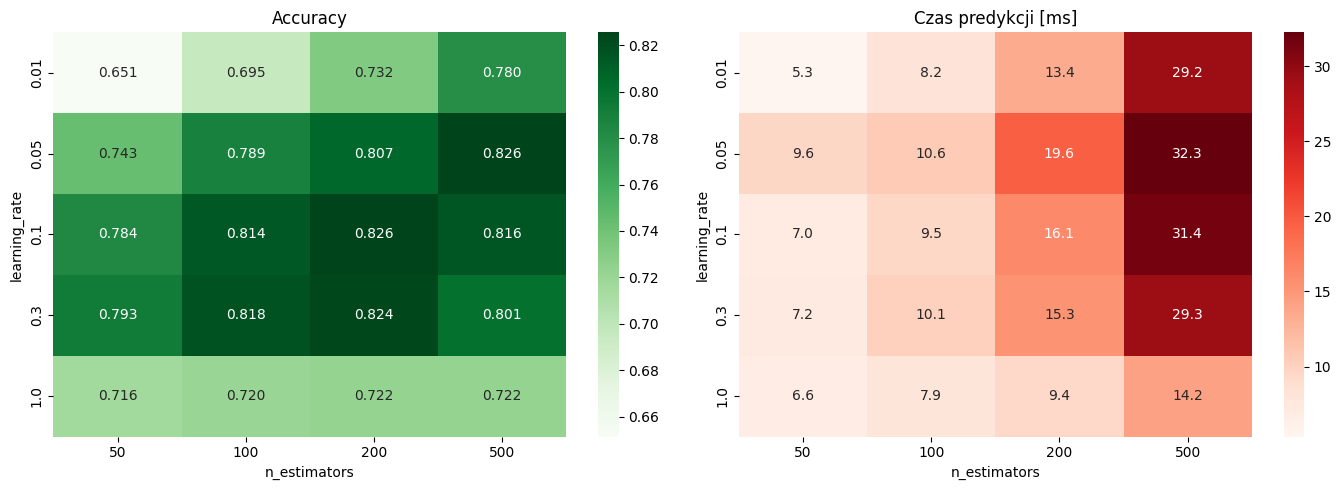

Top 5 konfiguracji:


,learning_rate,n_estimators,accuracy,confidence,pred_time_ms
7,0.05,500,0.8257,0.8368,32.2512
10,0.10,200,0.8257,0.8167,16.1018
14,0.30,200,0.8238,0.9053,15.2833
13,0.30,100,0.8180,0.8610,10.0855
11,0.10,500,0.8161,0.8911,31.4391


In [21]:
lr_values = [0.01, 0.05, 0.1, 0.3, 1.0]
n_values = [50, 100, 200, 500]

grid_results = []
for lr in lr_values:
    for n in n_values:
        r = evaluate_model(
            f'GBM(lr={lr}, n={n})',
            GradientBoostingClassifier(
                n_estimators=n, learning_rate=lr, max_depth=3, random_state=42
            ),
            X_train, X_test, y_train, y_test
        )
        r['learning_rate'] = lr
        r['n_estimators'] = n
        grid_results.append(r)

df_grid = pd.DataFrame(grid_results)

# heatmapa accuracy
pivot_acc = df_grid.pivot(index='learning_rate', columns='n_estimators', values='accuracy')
pivot_time = df_grid.pivot(index='learning_rate', columns='n_estimators', values='pred_time_ms')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(pivot_acc, annot=True, fmt='.3f', cmap='Greens', ax=axes[0])
axes[0].set_title('Accuracy')

sns.heatmap(pivot_time, annot=True, fmt='.1f', cmap='Reds', ax=axes[1])
axes[1].set_title('Czas predykcji [ms]')
plt.tight_layout()
plt.show()

print("Top 5 konfiguracji:")
df_grid.nlargest(5, 'accuracy')[['learning_rate','n_estimators','accuracy','confidence','pred_time_ms']].round(4)

### Podsumowanie Boostingu

AdaBoost z stump i regresja logistyczną nie działa dla naszego problemu. Confidence degeneruje do około 15%, czyli model praktycznie zgaduje. Nawet z głębszym drzewem (depth=3) AdaBoost daje 70.9%, czyli gorzej niż pojedyncze drzewo.

GradientBoosting osiągnąl najlepsze wyniki: 82.6% accuracy, a do tego jest szybszy od baggingu (17ms vs 30-40ms predykcji).

W trade-offie n_estimators i learning_rate widać klasyczną zależność: niski learning_rate wymaga więcej estymatorów żeby się nauczyć, a lr=1.0 nie zbiega się w ogóle. Najlepszy kompromis to lr=0.1 i n=200, dający najlepsze połaczenie (accuracy 0.83, confidence 0.82) przy 17ms predykcji.

## Stacking i Voting

In [ ]:
from sklearn.ensemble import VotingClassifier, StackingClassifier

# Bazowe modele - różna architektura
base_models = [
    ('tree', DecisionTreeClassifier(random_state=42)),
    ('logreg', LogisticRegression(max_iter=2000, random_state=42)),
    ('gbm', GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, 
                                        max_depth=3, random_state=42)),
]

ensemble_results = []

# Voting - hard (większościowe głosowanie)
ensemble_results.append(evaluate_model(
    'Voting(hard)',
    VotingClassifier(estimators=base_models, voting='hard'),
    X_train, X_test, y_train, y_test
))

# Voting - soft (uśrednianie prawdopodobieństw)
ensemble_results.append(evaluate_model(
    'Voting(soft)',
    VotingClassifier(estimators=base_models, voting='soft'),
    X_train, X_test, y_train, y_test
))

# Stacking
ensemble_results.append(evaluate_model(
    'Stacking(meta=LogReg)',
    StackingClassifier(
        estimators=base_models, 
        final_estimator=LogisticRegression(max_iter=2000, random_state=42),
        cv=5
    ),
    X_train, X_test, y_train, y_test
))

pd.DataFrame(ensemble_results).round(4)

### Podsumowanie Stackingu i Votingu

Voting(hard) dał 79.3% accuracy. Większościowe głosowanie 3 modeli wyszło lepiej niż średnia z nich, ale traci informację o pewności.

Voting(soft) dał gorszy wynik niż hard (78.0%). Uśrednianie prawdopodobieństw ciągnie zespół w stronę słabszego modelu, bo regresja logistyczna ma niskie acc, dlatego wynik jest zaniżony.

Stacking z meta-modelem LR wygrał z wynikiem 83.3%. Meta-model nauczył się, że GBM zwykle ma rację, drzewo czasem, a regresja logistyczna rzadko, i odpowiednio waży ich predykcje. Voting tego nie potrafi, bo traktuje wszystkie modele równo.

Stacking ma też najlepszą kalibrację pewności w całym zadaniu: accuracy 0.83 i confidence 0.81 są praktycznie równe, czyli model wie kiedy się myli.

## Porównanie końcowe wszystkich modeli

Zbieramy wyniki z wszystkich sekcji i wybieramy modele do rekomendacji.

In [ ]:
all_results = []

# Bazowe
all_results.extend(results)
# Bagging
all_results.extend(bagging_results)
# najlepsze warianty parametrów baggingu
all_results.extend(bootstrap_results[2:4])  # bootstrap_features=True
# Boosting
all_results.extend(boost_results)
# Najlepszy GBM z grid search
all_results.append(evaluate_model(
    'GBM(lr=0.1, n=200) [BEST]',
    GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42),
    X_train, X_test, y_train, y_test
    ))

# Voting + Stacking
all_results.extend(ensemble_results)

df_all = pd.DataFrame(all_results).round(4)
df_all = df_all.sort_values('accuracy', ascending=False).reset_index(drop=True)
df_all

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(df_all['pred_time_ms'], df_all['accuracy'], 
                     s=200, alpha=0.6, c=range(len(df_all)), cmap='viridis')

for i, row in df_all.iterrows():
    ax.annotate(row['model'], 
                (row['pred_time_ms'], row['accuracy']),
                fontsize=8, xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('Czas predykcji [ms]')
ax.set_ylabel('Accuracy')
ax.set_title('dokładność vs czas predykcji')
ax.grid(True, alpha=0.3)
ax.axhline(y=0.80, color='r', linestyle='--', alpha=0.3, label='acc=0.80')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_model = Pipeline([
    ('prep', preprocessor),
    ('clf', GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42
    ))
])
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best, labels=order)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(cm, display_labels=order)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
ax.set_title('Confusion matrix - GradientBoosting (rekomendowany model)')
plt.tight_layout()
plt.show()

## Wnioski dla Ministerstwa Zdrowia

Rekomendowany model to GradientBoosting (n_estimators=200, learning_rate=0.1). Daje 82.6% accuracy przy czasie predykcji 11ms i dobrze skalibrowanej pewności (confidence 0.82). Błędy ograniczone do sąsiednich klas, czyli model nie myli osoby zdrowej z ciężko chorą.

Bagging z bootstrap_features dał 84.1%, ale przy trzykrotnie dłuższym czasie predykcji i gorszej kalibracji. 1.5 punktu procentowego nie uzasadnia tej różnicy w wiejskich przychodniach.

AdaBoost, bagging na płytkich drzewach i bagging na regresji logistycznej nie nadają się do wdrożenia. AdaBoost dla 7 klas praktycznie zgaduje, bagging na płytkich drzewach ma 50% accuracy, a bagging na LR daje to samo co sama LR przy ośmiokrotnie wyższym koszcie.

Główne ograniczenie modelu: 77% danych pochodzi z SMOTE-NC. Widać to po fałszywej zależności między płcią a klasą otyłości (Obesity_II to 99% mężczyzn, Obesity_III to 100% kobiet).